# **Task-1:Environment setup and Data pipeline**

**Framework Used:TensorFlow/Keras**


Importing Libraries and setting random seeds to 42

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import os
import random
import matplotlib.pyplot as plt
from tensorflow.keras import layers,models,regularizers
# Setting all random seeds to 42
random.seed(42) # random.seed controls Python's random operations
np.random.seed(42) # np.random.seed controls NumPy based randomness
tf.random.set_seed(42) # tf.random.set_seed controls TensorFlow randomness

**Problem1:Environment verification**

In [3]:
print("NumPy version :", np.__version__)
print("Pandas version :", pd.__version__)
print("TensorFlow version :", tf.__version__)
print("Matplotlib version :", plt.matplotlib.__version__)

gpus=tf.config.list_physical_devices("GPU")
print("Available GPUs :", gpus)

NumPy version : 2.0.2
Pandas version : 2.2.2
TensorFlow version : 2.19.0
Matplotlib version : 3.10.0
Available GPUs : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


- we see no GPU available so training will run on CPU.
- CPU training is slower because matrix operations can not work as in parallel as they do on GPU.
- On a GPU machine it would be easier to train larger models faster.

**Problem2:Dataset exploration**

**Loading datasets**

In [4]:
# loading mnist
(mnist_x_train,mnist_y_train),(mnist_x_test,mnist_y_test)=tf.keras.datasets.mnist.load_data()
# loading cifar10
(cifar_x_train,cifar_y_train),(cifar_x_test,cifar_y_test)=tf.keras.datasets.cifar10.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Inspecting shapes,dtype,value range

In [5]:
print("MNIST training image shape :", mnist_x_train.shape)
print("MNIST test image shape     :", mnist_x_test.shape)
print("MNIST training labels shape:", mnist_y_train.shape)
print("MNIST test labels shape    :", mnist_y_test.shape)
print()
print("CIFAR-10 training image shape :", cifar_x_train.shape)
print("CIFAR-10 test image shape     :", cifar_x_test.shape)
print("CIFAR-10 training labels shape:", cifar_y_train.shape)
print("CIFAR-10 test labels shape    :", cifar_y_test.shape)
print(" Data Types ")
print("MNIST image dtype   :", mnist_x_train.dtype)
print("MNIST label dtype   :", mnist_y_train.dtype)
print("CIFAR image dtype   :", cifar_x_train.dtype)
print("CIFAR label dtype   :", cifar_y_train.dtype)
print(" Pixel value ranges before Preprocessing ")
print("MNIST min value :", mnist_x_train.min(), " max value :", mnist_x_train.max())
print("CIFAR min value :", cifar_x_train.min(), " max value :", cifar_x_train.max())

MNIST training image shape : (60000, 28, 28)
MNIST test image shape     : (10000, 28, 28)
MNIST training labels shape: (60000,)
MNIST test labels shape    : (10000,)

CIFAR-10 training image shape : (50000, 32, 32, 3)
CIFAR-10 test image shape     : (10000, 32, 32, 3)
CIFAR-10 training labels shape: (50000, 1)
CIFAR-10 test labels shape    : (10000, 1)
 Data Types 
MNIST image dtype   : uint8
MNIST label dtype   : uint8
CIFAR image dtype   : uint8
CIFAR label dtype   : uint8
 Pixel value ranges before Preprocessing 
MNIST min value : 0  max value : 255
CIFAR min value : 0  max value : 255


MNIST class balance

In [6]:
mnist_class_counts = np.bincount(mnist_y_train)

print("MNIST training samples per class:\n")
for digit, count in enumerate(mnist_class_counts):
    print(f"Class {digit}: {count}")


MNIST training samples per class:

Class 0: 5923
Class 1: 6742
Class 2: 5958
Class 3: 6131
Class 4: 5842
Class 5: 5421
Class 6: 5918
Class 7: 6265
Class 8: 5851
Class 9: 5949


It is balanced because all classes have similar number of samples

Plot

/tmp/ipykernel_669/463744777.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax[1][i].set_title(classes[int(label)])


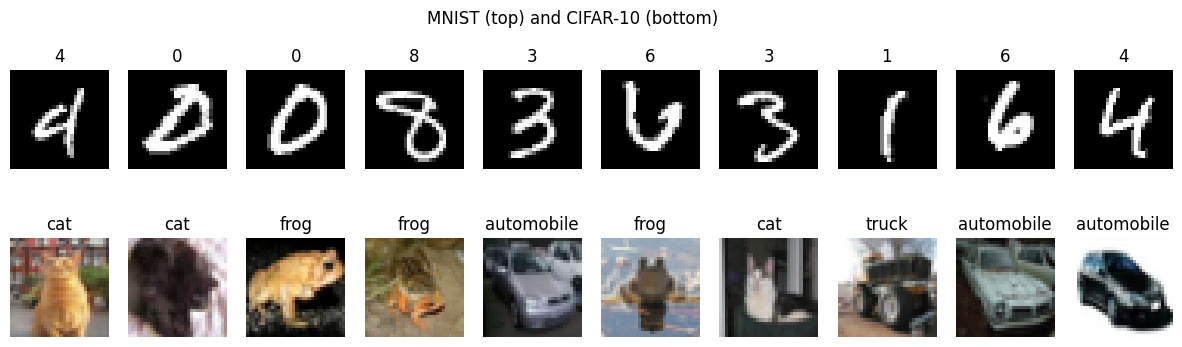

In [7]:
# class names for CIFAR-10
classes = ["airplane","automobile","bird","cat","deer",
           "dog","frog","horse","ship","truck"]

# picking 10 random images
mnist_idx = np.random.randint(0, len(mnist_x_train), 10)
cifar_idx = np.random.randint(0, len(cifar_x_train), 10)

fig, ax = plt.subplots(2, 10, figsize=(15,4))

# MNIST images (top row)
for i in range(10):
    ax[0][i].imshow(mnist_x_train[mnist_idx[i]], cmap='gray')
    ax[0][i].set_title(str(mnist_y_train[mnist_idx[i]]))
    ax[0][i].axis("off")

# CIFAR images (bottom row)
for i in range(10):
    img = cifar_x_train[cifar_idx[i]]
    label = cifar_y_train[cifar_idx[i]]

    ax[1][i].imshow(img)
    ax[1][i].set_title(classes[int(label)])
    ax[1][i].axis("off")

plt.suptitle("MNIST (top) and CIFAR-10 (bottom)")
plt.savefig("dataset_samples.png")
plt.show()

**Problem3:Preprocessing pipeline**

Preprocessing function

In [8]:
# function to preprocess data
def preprocess_data(images, labels, name):
    print("dataset:", name)
    # before preprocessing
    print("before")
    print("shape:", images.shape)
    print("dtype:", images.dtype)
    print("min:", images.min(), "max:", images.max())
    print("labels shape:", labels.shape)
    # normalizing
    images = images.astype("float32") / 255.0
    print("\nafter normalize")
    print("dtype:", images.dtype)
    print("min:", images.min(), "max:", images.max())
    # add channel if needed
    if len(images.shape) == 3:
        images = np.expand_dims(images, -1)
    print("\nafter reshape:", images.shape)
    # one hot encoding
    labels = tf.keras.utils.to_categorical(labels, 10)
    print("\nafter one hot:", labels.shape)
    return images, labels

preprocessing MNIST

In [9]:
# applying preprocessing on mnist train data
mnist_x_train_p, mnist_y_train_p = preprocess_data(mnist_x_train, mnist_y_train, "mnist train")

# applying preprocessing on mnist test data
mnist_x_test_p, mnist_y_test_p = preprocess_data(mnist_x_test, mnist_y_test, "mnist test")

dataset: mnist train
before
shape: (60000, 28, 28)
dtype: uint8
min: 0 max: 255
labels shape: (60000,)

after normalize
dtype: float32
min: 0.0 max: 1.0

after reshape: (60000, 28, 28, 1)

after one hot: (60000, 10)
dataset: mnist test
before
shape: (10000, 28, 28)
dtype: uint8
min: 0 max: 255
labels shape: (10000,)

after normalize
dtype: float32
min: 0.0 max: 1.0

after reshape: (10000, 28, 28, 1)

after one hot: (10000, 10)


**Problem4:Data Augmentation Pipeline**

Creating augmentaion layers

In [10]:
# creating augmentation layers
aug = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),   # flip image left-right
    tf.keras.layers.RandomRotation(0.1),        # small rotation
    tf.keras.layers.RandomZoom(0.1)             # slight zoom
])

Augmentation results

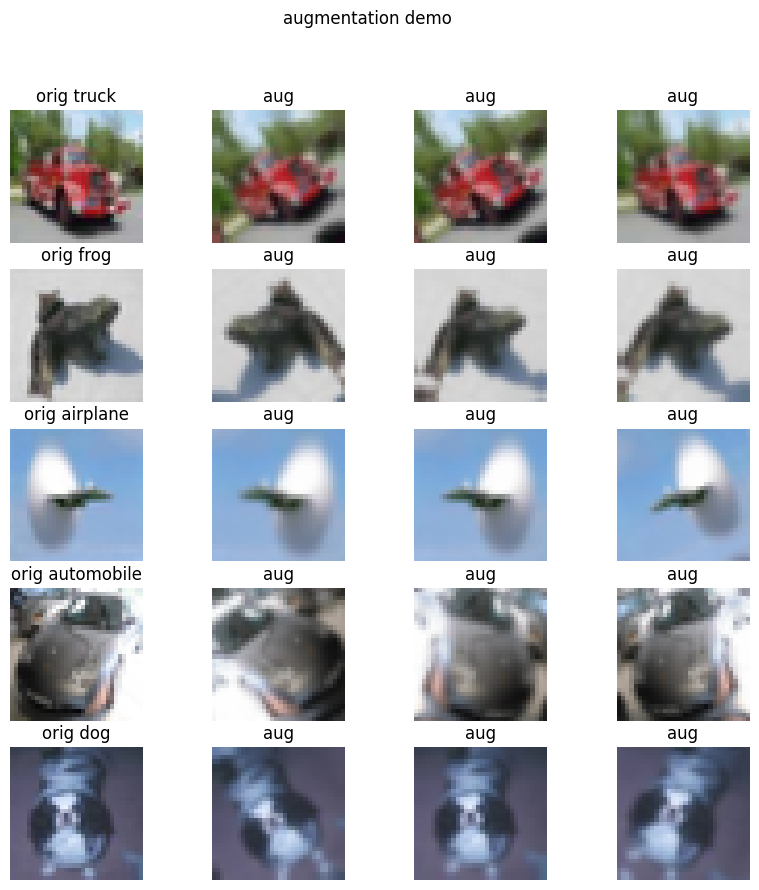

In [11]:
# taking 5 random images
idx = np.random.randint(0, len(cifar_x_train), 5)
fig, ax = plt.subplots(5, 4, figsize=(10,10))
for i in range(5):

    img = cifar_x_train[idx[i]]
    label = cifar_y_train[idx[i]][0]
    # original image
    ax[i][0].imshow(img)
    ax[i][0].set_title("orig " + classes[label])
    ax[i][0].axis("off")
    # augmented images
    for j in range(1,4):
        out = aug(tf.expand_dims(img, 0), training=True)
        out = tf.squeeze(out).numpy()
        out = np.clip(out, 0, 255).astype("uint8")
        ax[i][j].imshow(out)
        ax[i][j].set_title("aug")
        ax[i][j].axis("off")

plt.suptitle("augmentation demo")
plt.savefig("augmentation_demo.png")
plt.show()

**ANALYSIS & REFLECTION QUESTIONS**

Answer1:
- The channel dimension represents how many values each pixel has
- For grayscale images like MNIST, each pixel has only one value so the shape is (N, H, W, 1)
- For RGB images like CIFAR-10, each pixel has three values (red, green, blue) so the shape is (N, H, W, 3)

Answer2:
- If the image size is very large like 1024x1024, it can take a lot of memory. One way to handle this is by resizing the images to a smaller size before training.
- Another method is using smaller batch sizes so that fewer images are processed at once.
- We can also use cropping or patch-based training where we divide large images into smaller parts and train on those.
- These methods help in reducing memory usage and make training possible.

Answer3:
- This is wrong because it uses information from the test set, which should not be used during preprocessing.
- The test set is supposed to be completely unseen data. If we calculate mean and standard deviation from the test set, it leads to data leakage.
- The correct approach is to calculate these values using only the training data and then apply them to both validation and test sets.

###**Task2:Building a CNN from scratch**

**Manual 2D convolution**

conv2d function

In [12]:
# function for 2d convolution using only numpy
def conv2d(image, kernel, stride=1, padding=0):

    # add zero padding if needed
    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding)), mode="constant")

    h, w = image.shape
    kh, kw = kernel.shape

    out_h = ((h - kh) // stride) + 1
    out_w = ((w - kw) // stride) + 1

    out = np.zeros((out_h, out_w))

    for i in range(out_h):
        for j in range(out_w):
            patch = image[i*stride:i*stride+kh, j*stride:j*stride+kw]
            out[i, j] = np.sum(patch * kernel)

    return out

Testing image, kernel

In [13]:
img = np.array([
    [3, 1, 0, 2, 4],
    [1, 5, 3, 2, 1],
    [0, 2, 6, 4, 3],
    [2, 3, 1, 5, 2],
    [1, 0, 2, 3, 4]
])
kernel = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

out = conv2d(img, kernel, stride=1, padding=0)

print("Input image:\n", img)
print("Kernel:\n", kernel)
print("Output:\n", out)
print("Output shape:", out.shape)

Input image:
 [[3 1 0 2 4]
 [1 5 3 2 1]
 [0 2 6 4 3]
 [2 3 1 5 2]
 [1 0 2 3 4]]
Kernel:
 [[-1  0  1]
 [-2  0  2]
 [-1  0  1]]
Output:
 [[ 7. -3. -3.]
 [13.  3. -7.]
 [ 5.  9.  1.]]
Output shape: (3, 3)


Manual shape veriffication

In [14]:
n = 5
f = 3
p = 0
s = 1
out_size = ((n - f + 2*p) // s) + 1
print("Output size formula result:", out_size, "x", out_size)

Output size formula result: 3 x 3


**Problem2:Output Size Derivation**

Formula used:
Output size = floor((N - F + 2P) / S) + 1
a)Input = 28x28, Kernel = 5x5, Padding = 0, Stride = 1
Output = ((28 - 5 + 2x0) / 1) + 1

=24

Final output size =24 x 24

b)Input = 28x28, Kernel = 3x3, Padding = 1, Stride = 1
Output = ((28-3+2x1)/1)+1

=28

Final output size =28 x 28

c)Input = 32x32, Kernel = 3x3, Padding = 0, Stride = 2
Output = ((32-3+0)/2)+1
=floor(29/2)+1
=15

Final output size =15x15

d)First Conv layer: K = 3, P = 1, S = 1 on 32x32

Output = ((32 - 3 + 2x1) / 1) + 1  
= 32

So after first layer = 32x32

Second Conv layer: K = 3, P = 0, S = 1 on 32x32

Output = ((32 - 3 + 0) / 1) + 1  
= 30

Final output size = 30x30


**Problem3:Implement LeNet-5**

Building LeNet-5

In [15]:
# lenet 5 model
lenet = models.Sequential()

lenet.add(layers.Input(shape=(28, 28, 1)))

lenet.add(layers.Conv2D(6, (5,5), activation="tanh", padding="valid"))
lenet.add(layers.AveragePooling2D(pool_size=(2,2), strides=2))

lenet.add(layers.Conv2D(16, (5,5), activation="tanh", padding="valid"))
lenet.add(layers.AveragePooling2D(pool_size=(2,2), strides=2))

lenet.add(layers.Flatten())
lenet.add(layers.Dense(120, activation="tanh"))
lenet.add(layers.Dense(84, activation="tanh"))
lenet.add(layers.Dense(10, activation="softmax"))

Summary

In [16]:
lenet.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

Verifying parameter count

In [17]:
print("Total params:", lenet.count_params())

Total params: 44426


b)For the first Conv2D layer:

Formula:
(KxKxC_in + 1)xC_out

Here,
K = 5  
C_in = 1  
C_out = 6

So,
(5x5x1+1)x6  
= (25 + 1) × 6  
= 26x6  
= 156

So the first convolution layer has 156 parameters.

The total number of parameters in the LeNet-5 model is 44,426, which matches the model summary.

c)AvgPooling was used in LeNet-5 because at that time it was commonly used to reduce spatial size smoothly by averaging nearby values. Today, MaxPooling is used more often because it keeps the strongest activation, which usually helps the model capture important features better.

**Problem4:Design a Custom CNN for CIFAR-10**

#Sketch
Input (32x32x3)  
- Conv(32, 3x3) → BatchNorm → ReLU → MaxPool  
- Conv(64, 3x3) → BatchNorm → ReLU → MaxPool  
- Conv(128, 3x3) → BatchNorm → ReLU → MaxPool  
- Conv(256, 3x3) → BatchNorm → ReLU → MaxPool  
- GlobalAveragePooling  
- Dropout(0.4)  
- Dense(128, ReLU)  
- Dense(10, Softmax)

**Design rationale**

here we used four convolution blocks so that the model can learn simple features in early layers and more complex features in deeper layers. Batch Normalisation is added to make training more stable, and ReLU is used because it works well in deep CNNs. Pooling gradually reduces spatial size and computation, also used GlobalAveragePooling before the Dense layers to reduce the number of parameters, and Dropout is added to reduce overfitting

Building custom CNN

In [18]:
# custom cnn for cifar 10
cnn = models.Sequential()
cnn.add(layers.Input(shape=(32, 32, 3)))
cnn.add(layers.Conv2D(32, (3,3), padding="same"))
cnn.add(layers.BatchNormalization())
cnn.add(layers.ReLU())
cnn.add(layers.MaxPooling2D((2,2)))

cnn.add(layers.Conv2D(64, (3,3), padding="same"))
cnn.add(layers.BatchNormalization())
cnn.add(layers.ReLU())
cnn.add(layers.MaxPooling2D((2,2)))

cnn.add(layers.Conv2D(128, (3,3), padding="same"))
cnn.add(layers.BatchNormalization())
cnn.add(layers.ReLU())
cnn.add(layers.MaxPooling2D((2,2)))

cnn.add(layers.Conv2D(256, (3,3), padding="same"))
cnn.add(layers.BatchNormalization())
cnn.add(layers.ReLU())
cnn.add(layers.MaxPooling2D((2,2)))

cnn.add(layers.GlobalAveragePooling2D())
cnn.add(layers.Dropout(0.4))
cnn.add(layers.Dense(128, activation="relu"))
cnn.add(layers.Dense(10, activation="softmax"))

Summary

In [19]:
cnn.summary()
print("Total params:", cnn.count_params())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 424,522 (1.62 MB)

 Trainable params: 423,562 (1.62 MB)

 Non-trainable params: 960 (3.75 KB)

Total params: 424522


**Analysis & Reflection Questions**

Answer1:
Two stacked 3x3 convolution layers are more parameter efficient than one 5x5 convolution layer when the number of input and output channels is the same.

For example, if input channels = output channels = C, then:

One 5x5 conv layer needs:
25C² parameters

Two 3x3 conv layers need:
9C² + 9C² = 18C² parameters

So two 3x3 layers use fewer parameters than one 5x5 layer.

Another advantage is that stacking two 3x3 layers adds one extra non-linearity between them, which helps the network learn more complex patterns. It also gives nearly the same receptive field as a 5x5 convolution, but in a more efficient way

Answer2:
Batch Normalisation helps make training more stable by normalising the activations during training. It is usually placed after the convolution layer and before the activation function.

So the usual order is:
Conv → BatchNorm → ReLU

This helps because the values passed to the activation function stay in a better range.

Two practical benefits are:
1. Training becomes faster and more stable.
2. The model can often use a higher learning rate and becomes less sensitive to initialization.

It also acts as a small regulariser in many cases

Answer3:
GlobalAveragePooling takes each feature map and computes a single average value from it. So if there are many feature maps, it converts each one into one number.

Geometrically, it means the spatial information is compressed into one average response per channel.

If we replace it with Flatten, the parameter count will increase a lot because all spatial values will be sent to the Dense layer. Flatten keeps more detailed spatial information, but it also increases memory use and the chance of overfitting.

GlobalAveragePooling reduces parameters and makes the model lighter, but some fine spatial details are lost

###**Task-3**:Training, Tuning & Regularisation

Preprocessing MNIST

In [20]:
mnist_x_train = mnist_x_train.astype("float32") / 255.0
mnist_x_test = mnist_x_test.astype("float32") / 255.0

mnist_x_train = np.expand_dims(mnist_x_train, -1)
mnist_x_test = np.expand_dims(mnist_x_test, -1)

mnist_y_train_ohe = tf.keras.utils.to_categorical(mnist_y_train, 10)
mnist_y_test_ohe = tf.keras.utils.to_categorical(mnist_y_test, 10)

Preprocessing CIFAR-10

In [21]:
cifar_x_train = cifar_x_train.astype("float32") / 255.0
cifar_x_test = cifar_x_test.astype("float32") / 255.0

cifar_y_train_ohe = tf.keras.utils.to_categorical(cifar_y_train, 10)
cifar_y_test_ohe = tf.keras.utils.to_categorical(cifar_y_test, 10)

Problem1:First Training run

In [22]:
# lenet model
def make_lenet():
    model = models.Sequential()
    model.add(layers.Input(shape=(28, 28, 1)))

    model.add(layers.Conv2D(6, (5,5), activation="tanh", padding="valid"))
    model.add(layers.AveragePooling2D(pool_size=(2,2), strides=2))

    model.add(layers.Conv2D(16, (5,5), activation="tanh", padding="valid"))
    model.add(layers.AveragePooling2D(pool_size=(2,2), strides=2))

    model.add(layers.Flatten())
    model.add(layers.Dense(120, activation="tanh"))
    model.add(layers.Dense(84, activation="tanh"))
    model.add(layers.Dense(10, activation="softmax"))

    return model

Training LeNet with SGD

In [23]:
lenet_sgd = make_lenet()
lenet_sgd.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
history_lenet_sgd = lenet_sgd.fit(
    mnist_x_train,
    mnist_y_train_ohe,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7839 - loss: 0.8995 - val_accuracy: 0.9055 - val_loss: 0.3849
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8932 - loss: 0.3884 - val_accuracy: 0.9285 - val_loss: 0.2769
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9116 - loss: 0.3100 - val_accuracy: 0.9378 - val_loss: 0.2296
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9236 - loss: 0.2647 - val_accuracy: 0.9455 - val_loss: 0.1979
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9322 - loss: 0.2310 - val_accuracy: 0.9513 - val_loss: 0.1737
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9401 - loss: 0.2041 - val_accuracy: 0.9563 - val_loss: 0.1543
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9467 - loss: 0.1819 - val_accuracy: 0.9613 - val_loss: 0.1385
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9517 - loss: 0.1634 - val_accuracy: 0.

Test accuracy

In [24]:
test_loss, test_acc = lenet_sgd.evaluate(mnist_x_test, mnist_y_test_ohe, verbose=0)
print("final test accuracy:", test_acc)

final test accuracy: 0.9739999771118164


Finding overfitting epoch

In [25]:
train_loss = history_lenet_sgd.history["loss"]
val_loss = history_lenet_sgd.history["val_loss"]

overfit_epoch = None
for i in range(1, len(val_loss)):
    if val_loss[i] > val_loss[i-1] and train_loss[i] < train_loss[i-1]:
        overfit_epoch = i + 1
        break

print("overfitting starts at epoch:", overfit_epoch)

overfitting starts at epoch: None


Ploting loss and accuracy

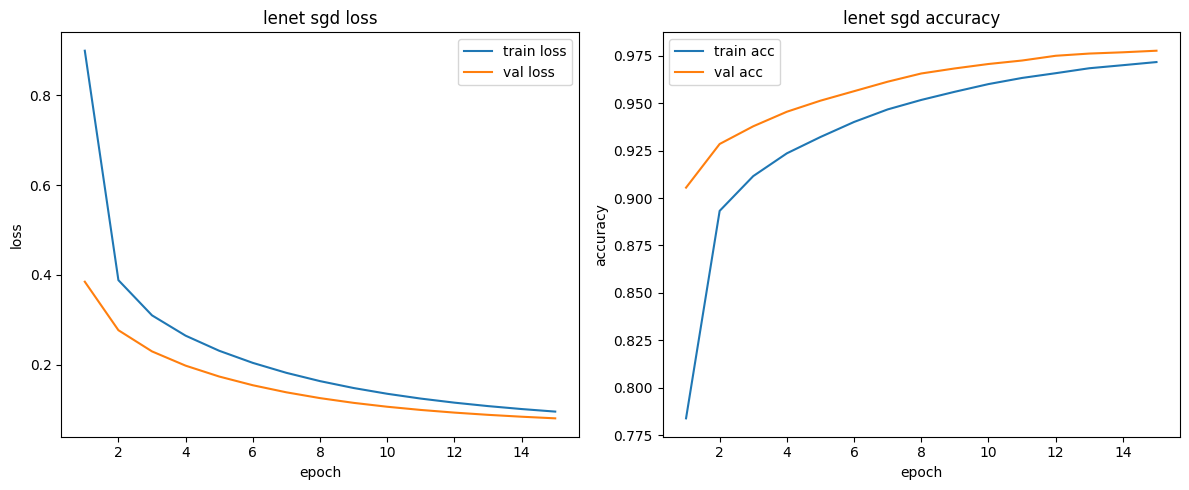

In [26]:
e = range(1, 16)

plt.figure(figsize=(12,5))

# loss graph
plt.subplot(1,2,1)
plt.plot(e, history_lenet_sgd.history["loss"], label="train loss")
plt.plot(e, history_lenet_sgd.history["val_loss"], label="val loss")

if overfit_epoch != None:
    plt.axvline(overfit_epoch, linestyle="--", label="overfit")

plt.title("lenet sgd loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()

# accuracy graph
plt.subplot(1,2,2)
plt.plot(e, history_lenet_sgd.history["accuracy"], label="train acc")
plt.plot(e, history_lenet_sgd.history["val_accuracy"], label="val acc")

if overfit_epoch != None:
    plt.axvline(overfit_epoch, linestyle="--", label="overfit")

plt.title("lenet sgd accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()

plt.tight_layout()
plt.savefig("lenet_sgd_curves.png")
plt.show()

Problem2:Optimiser comparison

Training with 3 optimisers

In [30]:
def train_with_optimizer(opt):
    model = make_lenet()
    model.compile(
        optimizer=opt,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    history = model.fit(
        mnist_x_train,
        mnist_y_train_ohe,
        epochs=15,
        batch_size=64,
        validation_split=0.1,
        verbose=0
    )
    return history

runnign all 3

In [38]:
hist_sgd = train_with_optimizer(tf.keras.optimizers.SGD(learning_rate=0.01))
hist_mom = train_with_optimizer(tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9))
hist_adam = train_with_optimizer(tf.keras.optimizers.Adam(learning_rate=0.001))

Ploting validation accuracy comparison

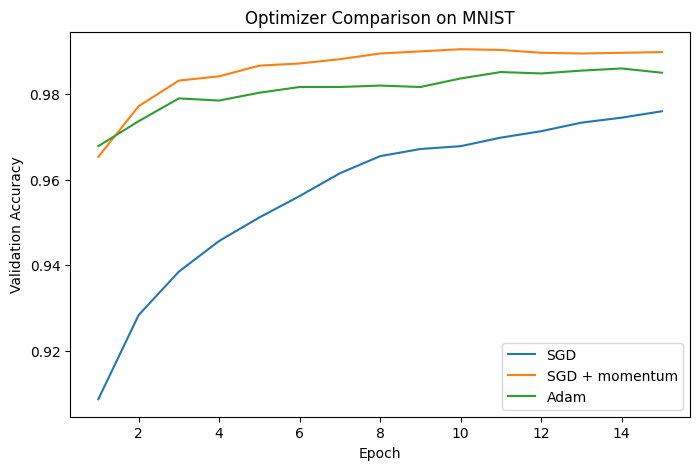

In [32]:
epochs = range(1, 16)

plt.figure(figsize=(8,5))
plt.plot(epochs, hist_sgd.history["val_accuracy"], label="SGD")
plt.plot(epochs, hist_mom.history["val_accuracy"], label="SGD + momentum")
plt.plot(epochs, hist_adam.history["val_accuracy"], label="Adam")
plt.title("Optimizer Comparison on MNIST")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.savefig("optimiser_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

**Problem 3 — Learning rate and batch size grid search**

Custom CNN function

In [33]:
# custom cnn for cifar10
def make_custom_cnn():
    model = models.Sequential()

    model.add(layers.Input(shape=(32, 32, 3)))

    model.add(layers.Conv2D(32, (3,3), padding="same"))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Conv2D(64, (3,3), padding="same"))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Conv2D(128, (3,3), padding="same"))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dropout(0.4))
    model.add(layers.Dense(128, activation="relu"))
    model.add(layers.Dense(10, activation="softmax"))

    return model

Grid Search

In [34]:
lrs = [0.1, 0.01, 0.001]
batches = [32, 128]
results = np.zeros((3, 2))
for i, lr in enumerate(lrs):
    for j, bs in enumerate(batches):
        print("training for lr =", lr, "batch size =", bs)
        model = make_custom_cnn()
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
            loss="categorical_crossentropy",
            metrics=["accuracy"]
        )
        hist = model.fit(
            cifar_x_train,
            cifar_y_train_ohe,
            epochs=10,
            batch_size=bs,
            validation_split=0.1,
            verbose=0
        )
        results[i, j] = hist.history["val_accuracy"][-1]

training for lr = 0.1 batch size = 32
training for lr = 0.1 batch size = 128
training for lr = 0.01 batch size = 32
training for lr = 0.01 batch size = 128
training for lr = 0.001 batch size = 32
training for lr = 0.001 batch size = 128


Showing result table

In [35]:
print("final validation accuracy table")
print()
print(" batch32  batch128")
for i in range(3):
    print("lr", lrs[i], " ", round(results[i,0], 4), "     ", round(results[i,1], 4))

best_idx = np.unravel_index(np.argmax(results), results.shape)
print("\nbest combination:")
print("learning rate =", lrs[best_idx[0]])
print("batch size =", batches[best_idx[1]])
print("best val accuracy =", results[best_idx])

final validation accuracy table

 batch32  batch128
lr 0.1   0.097       0.2948
lr 0.01   0.7342       0.644
lr 0.001   0.6936       0.5636

best combination:
learning rate = 0.01
batch size = 32
best val accuracy = 0.7342000007629395


**Problem4:Regularisation experiment**

CNN variants

In [36]:
def make_simple_cnn(mode):

    model = models.Sequential()
    model.add(layers.Input(shape=(32,32,3)))
    # first conv block
    if mode == "bn" or mode == "both":
        model.add(layers.Conv2D(32, (3,3), padding="same"))
        model.add(layers.BatchNormalization())
        model.add(layers.ReLU())
    else:
        model.add(layers.Conv2D(32, (3,3), activation="relu", padding="same"))

    model.add(layers.MaxPooling2D((2,2)))

    if mode == "dropout" or mode == "both":
        model.add(layers.Dropout(0.3))
    # second conv block
    if mode == "bn" or mode == "both":
        model.add(layers.Conv2D(64, (3,3), padding="same"))
        model.add(layers.BatchNormalization())
        model.add(layers.ReLU())
    else:
        model.add(layers.Conv2D(64, (3,3), activation="relu", padding="same"))

    model.add(layers.MaxPooling2D((2,2)))
    if mode == "dropout" or mode == "both":
        model.add(layers.Dropout(0.3))
    model.add(layers.Flatten())
    if mode == "dropout" or mode == "both":
        model.add(layers.Dropout(0.5))

    model.add(layers.Dense(128, activation="relu"))
    model.add(layers.Dense(10, activation="softmax"))

    return model

Training all variants

In [37]:
modes = ["none", "dropout", "bn", "both"]
histories = {}
gaps = {}
for m in modes:
    print("training:", m)
    model = make_simple_cnn(m)
    model.compile(optimizer="adam",
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])
    h = model.fit(cifar_x_train,
                  cifar_y_train_ohe,
                  epochs=20,
                  batch_size=64,
                  validation_split=0.1,
                  verbose=0)
    histories[m] = h
    train_acc = h.history["accuracy"][-1]
    val_acc = h.history["val_accuracy"][-1]
    gaps[m] = train_acc - val_acc

training: none
training: dropout
training: bn
training: both


Ploting both training and validation accuracy for variants

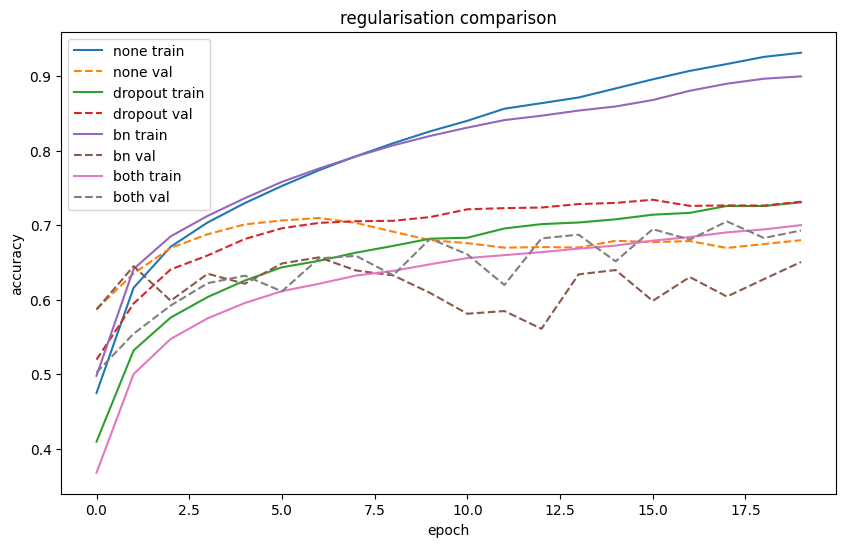

In [40]:
plt.figure(figsize=(10,6))
# plotting train and validation accuracy
for m in modes:
    plt.plot(histories[m].history["accuracy"], label=m + " train")
    plt.plot(histories[m].history["val_accuracy"], "--", label=m + " val")
plt.title("regularisation comparison")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.show()

Gap table

In [41]:
print("train-val accuracy gaps")
print()
for mode in modes:
    print(mode, ":", round(gaps[mode], 4))
best_mode = min(gaps, key=gaps.get)
print("\nbest variant based on smallest gap:", best_mode)

train-val accuracy gaps

none : 0.2513
dropout : -0.0008
bn : 0.2488
both : 0.0072

best variant based on smallest gap: dropout


**Problem5:Learning rate scheduling**




Picking best mode

In [42]:
best_mode_name = best_mode
print("using best mode:", best_mode_name)

using best mode: dropout


**ReduceLROnPlateau training**

In [43]:
model_plateau = make_simple_cnn(best_mode_name)
model_plateau.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
plateau_cb = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    verbose=1
)
hist_plateau = model_plateau.fit(
    cifar_x_train,
    cifar_y_train_ohe,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[plateau_cb],
    verbose=0
)


Epoch 26: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.


Cosine decay training

In [44]:
cosine_lr = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.001,
    decay_steps=30
)
model_cosine = make_simple_cnn(best_mode_name)
model_cosine.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=cosine_lr),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
hist_cosine = model_cosine.fit(
    cifar_x_train,
    cifar_y_train_ohe,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    verbose=0
)

Collect learning rates for plotting

In [45]:
lr_plateau = []
for i in range(30):
    lr_plateau.append(float(model_plateau.optimizer.learning_rate.numpy()))

lr_cosine = []
for step in range(30):
    lr_cosine.append(float(cosine_lr(step).numpy()))

Tracking LR properly

In [46]:
plateau_lr_list = []
class LRLogger(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        lr = self.model.optimizer.learning_rate
        if hasattr(lr, "numpy"):
            plateau_lr_list.append(float(lr.numpy()))
        else:
            plateau_lr_list.append(float(tf.keras.backend.get_value(lr)))

Re run plateau fit with both callbacks:

In [47]:
model_plateau = make_simple_cnn(best_mode_name)
model_plateau.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
plateau_lr_list = []
hist_plateau = model_plateau.fit(
    cifar_x_train,
    cifar_y_train_ohe,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[plateau_cb, LRLogger()],
    verbose=0
)
cosine_lr_list = [float(cosine_lr(i).numpy()) for i in range(30)]


Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 12: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 15: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 18: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.

Epoch 21: ReduceLROnPlateau reducing learning rate to 7.812500371073838e-06.

Epoch 24: ReduceLROnPlateau reducing learning rate to 3.906250185536919e-06.

Epoch 27: ReduceLROnPlateau reducing learning rate to 1.9531250927684596e-06.

Epoch 30: ReduceLROnPlateau reducing learning rate to 9.765625463842298e-07.


Plotting comparison

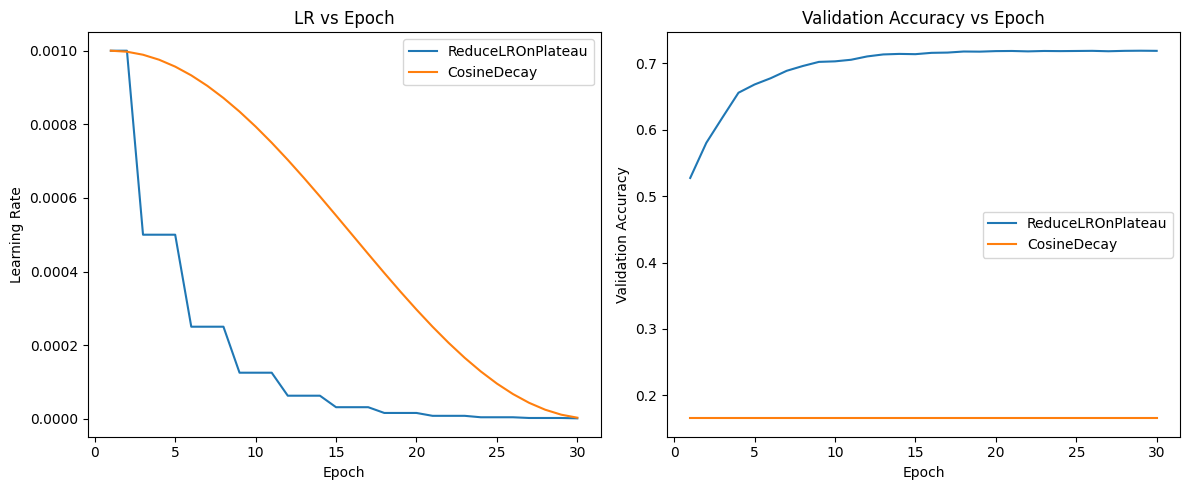

In [48]:
epochs = range(1, 31)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, plateau_lr_list, label="ReduceLROnPlateau")
plt.plot(epochs, cosine_lr_list, label="CosineDecay")
plt.title("LR vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.legend()
plt.subplot(1,2,2)
plt.plot(epochs, hist_plateau.history["val_accuracy"], label="ReduceLROnPlateau")
plt.plot(epochs, hist_cosine.history["val_accuracy"], label="CosineDecay")
plt.title("Validation Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.savefig("lr_schedule_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

##**Analysis questions**

Answer1:

A very high learning rate can make training unstable because the update steps become too large. Instead of moving smoothly toward a minimum, the model may jump across the loss surface and miss the low-loss region again and again.

This can cause the loss to oscillate a lot or even increase instead of decreasing. In some cases, the model may diverge completely because each step overshoots the minimum.

So the learning rate should be large enough for fast learning, but not so large that the optimisation becomes unstable.

Answer2:

From the grid search, the best accuracy came from [fill best combination], while the worst result came from [fill worst combination].

A possible reason is that learning rate controls how aggressively the model updates its weights, and batch size affects how noisy or stable each update is. If the learning rate is too high, training becomes unstable. If it is too low, training becomes slow. Smaller batch sizes can sometimes help the model explore better, while larger batch sizes may give smoother but less frequent updates.

So the pattern in the results is expected because both learning rate and batch size directly affect optimisation behaviour.

Answer3:

Dropout is disabled during inference because at test time we want the full network to be used for prediction. During training, dropout randomly turns off some neurons to reduce overfitting, but during testing we need stable and consistent outputs.

If a network has Dropout(0.5), then half of the activations are dropped during training on average. To keep the expected output magnitude the same, the surviving activations are scaled by 1 / (1 - 0.5) = 2 during training.

This is why at inference time dropout can simply be turned off, because the scaling has already been handled.

Answer4:

ReduceLROnPlateau reduces the learning rate only when the validation metric stops improving for some time. So its trigger depends on the model's training behaviour.

Cosine Annealing does not wait for validation performance. It changes the learning rate smoothly according to a cosine-shaped schedule over time.

So the LR curve of ReduceLROnPlateau usually looks like stepwise drops, while Cosine Annealing looks smooth and gradual.

ReduceLROnPlateau is better when we want the schedule to react to validation performance. Cosine Annealing is better when we want a smooth predefined schedule throughout training.

###**Task4:Visualisation & Interpretability**

**Problem1:Visualise Learned Filters**

Getting first conv filter

In [52]:
# getting weights from first conv layer
for layer in cnn.layers:
    if isinstance(layer, tf.keras.layers.Conv2D):
        w = layer.get_weights()[0]
        print("layer name:", layer.name)
        print("weight shape:", w.shape)
        break

layer name: conv2d_2
weight shape: (3, 3, 3, 32)


plot filters

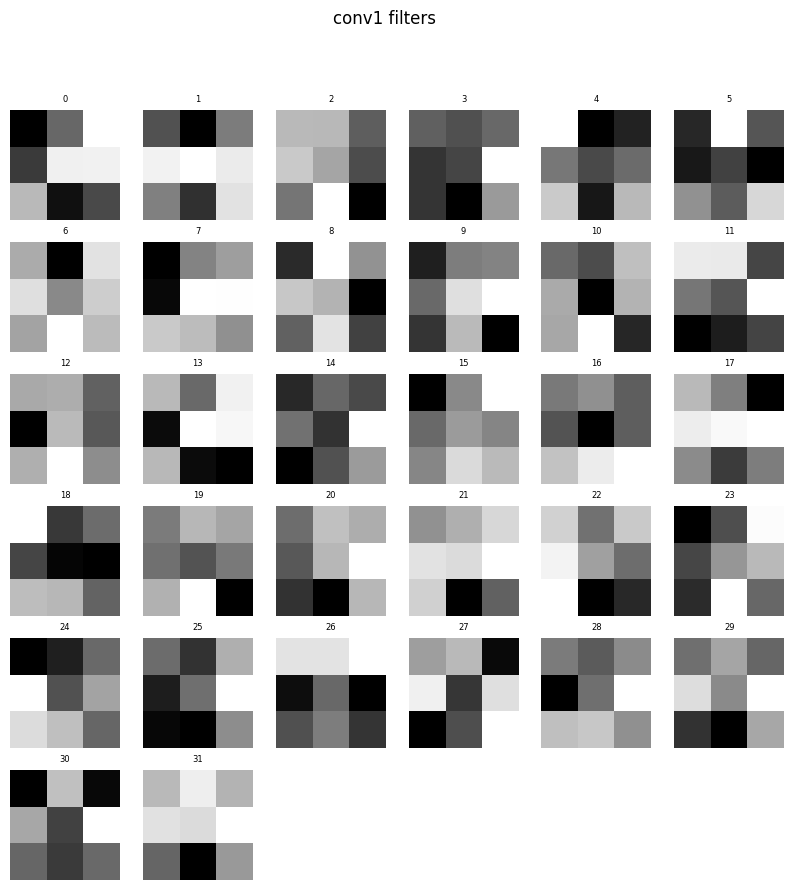

In [54]:
f = w.shape[3]
plt.figure(figsize=(10,10))
for i in range(f):
    filt = w[:,:,:,i]
    # convert to grayscale
    filt = np.mean(filt, axis=2)
    filt = (filt - filt.min()) / (filt.max() - filt.min() + 1e-5)
    plt.subplot(6,6,i+1)
    plt.imshow(filt, cmap="gray")
    plt.axis("off")
    plt.title(str(i), fontsize=6)

plt.suptitle("conv1 filters")
plt.savefig("conv1_filters.png")
plt.show()

**Problem2:Feature Maps**

picking one correct image

In [60]:
# get predictions
pred = cnn.predict(cifar_x_test)
# find one correct image
for i in range(len(pred)):
    if np.argmax(pred[i]) == cifar_y_test[i]:
        img = cifar_x_test[i]
        label = cifar_y_test[i]
        break
print("label:", label)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
label: [4]


submodel for feature maps

In [63]:
# call model once
_ = cnn.predict(cifar_x_test[:1], verbose=0)

# outputs of conv layers
layer_outputs = [l.output for l in cnn.layers if "conv" in l.name]

# submodel
sub_model = tf.keras.models.Model(inputs=cnn.inputs, outputs=layer_outputs)

to get activations

In [64]:
acts = sub_model.predict(img.reshape(1,32,32,3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 581ms/step


first layer feature maps

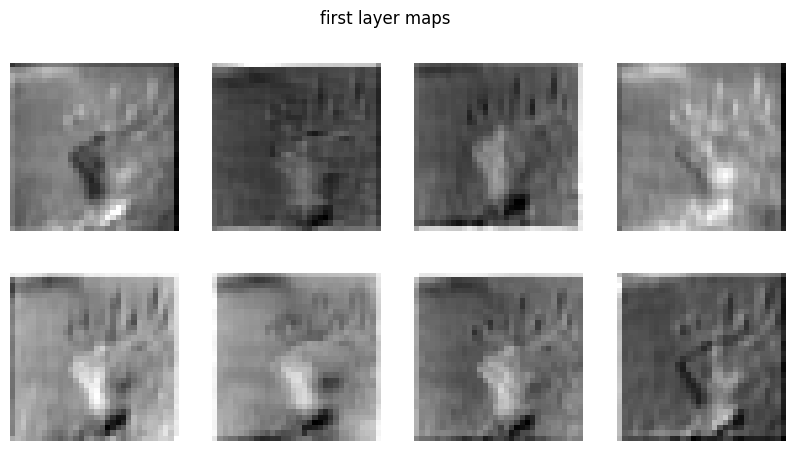

In [65]:
plt.figure(figsize=(10,5))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(acts[0][0,:,:,i], cmap="gray")
    plt.axis("off")
plt.suptitle("first layer maps")
plt.savefig("fmaps_layer1.png")
plt.show()

last layer feature maps

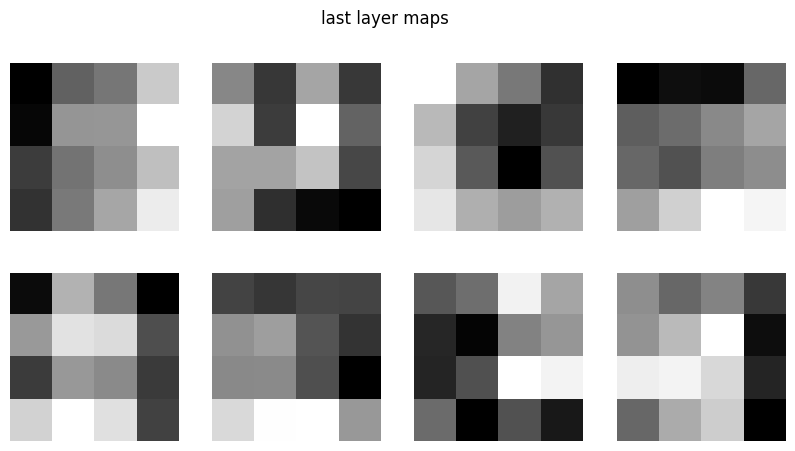

In [66]:
last = acts[-1]
plt.figure(figsize=(10,5))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(last[0,:,:,i], cmap="gray")
    plt.axis("off")
plt.suptitle("last layer maps")
plt.savefig("fmaps_last.png")
plt.show()

c)In the first layer, the feature maps are larger and easy to understand. They highlight simple features like edges and textures.

In the last layer, the feature maps are smaller and more abstract. It is harder to interpret them directly because they represent higher level features.

As depth increases, spatial size decreases but number of channels increases. Interpretability also decreases because features become more complex.

**Problem3:Grad-CAM Heatmap Implementation**

gradcam function

In [80]:
# gradcam function
def gradcam(img, model, class_idx):

    inp = tf.keras.Input(shape=(32,32,3))
    x = inp
    last_conv_out = None

    for layer in model.layers:
        x = layer(x)
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv_out = x

    grad_model = tf.keras.Model(inputs=inp, outputs=[last_conv_out, x])

    img = tf.cast(img, tf.float32)

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img, training=False)
        class_score = preds[:, class_idx]

    grads = tape.gradient(class_score, conv_out)

    pooled_grads = tf.reduce_mean(grads, axis=(1, 2))
    conv_out = conv_out[0]
    pooled_grads = pooled_grads[0]

    cam = tf.reduce_sum(conv_out * pooled_grads, axis=-1)
    cam = tf.nn.relu(cam)
    cam = cam / (tf.reduce_max(cam) + 1e-8)

    return cam.numpy()

applying gradcam

In [81]:
# applying gradcam
img1 = img.reshape(1,32,32,3).astype("float32")

pred_class = np.argmax(cnn.predict(img1, verbose=0))

cam1 = gradcam(img1, cnn, pred_class)

print(cam1.shape)

(4, 4)


show heatmap

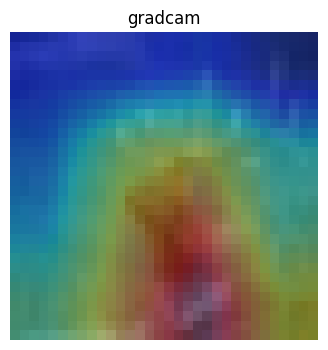

In [85]:
cam1_resized = tf.image.resize(cam1[..., np.newaxis], (32,32)).numpy().squeeze()
plt.figure(figsize=(4,4))
plt.imshow(img)
plt.imshow(cam1_resized, cmap="jet", alpha=0.4)
plt.title("gradcam")
plt.axis("off")
plt.savefig("gradcam_results.png")
plt.show()

Confusion matrix

In [83]:
y_pred = np.argmax(cnn.predict(cifar_x_test), axis=1)
y_true = cifar_y_test

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [86]:
y_pred_prob = cnn.predict(cifar_x_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = cifar_y_test

print("unique predicted classes:", np.unique(y_pred))
print("prediction count:", np.bincount(y_pred))

unique predicted classes: [0 4 7]
prediction count: [1162    0    0    0 8829    0    0    9]


3Classified images

In [92]:
correct_idx = []

pred_all = np.argmax(cnn.predict(cifar_x_test, verbose=0), axis=1)

for i in range(len(cifar_x_test)):
    if pred_all[i] == cifar_y_test[i]:
        correct_idx.append(i)
    if len(correct_idx) == 3:
        break

print(correct_idx)

[22, 26, 32]


Get 1 misclassified image

In [93]:
wrong_idx = None

for i in range(len(cifar_x_test)):
    if pred_all[i] != cifar_y_test[i]:
        wrong_idx = i
        break

print(wrong_idx)

0


Generate Grad-CAM for 3 correct images + 1 wrong image

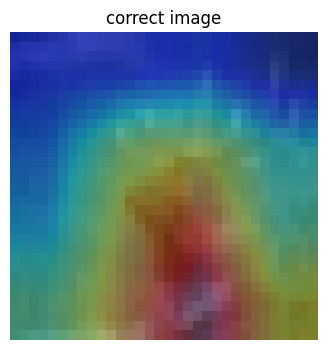

In [94]:
i = correct_idx[0]

img = cifar_x_test[i]
img1 = img.reshape(1,32,32,3).astype("float32")

pred_class = np.argmax(cnn.predict(img1, verbose=0))
cam1 = gradcam(img1, cnn, pred_class)

cam1 = tf.image.resize(cam1[..., np.newaxis], (32,32)).numpy().squeeze()

plt.figure(figsize=(4,4))
plt.imshow(img)
plt.imshow(cam1, cmap="jet", alpha=0.4)
plt.title("correct image")
plt.axis("off")
plt.show()

#**Analysis Questions**

Answer1:
The Grad-CAM result shows that when the model correctly classifies a cat, it focuses on the face region, which is a meaningful and important feature. However, for the misclassified image where a cat is predicted as a dog, the heatmap focuses more on the background instead of the object itself.

This suggests that the model has learned to rely on background patterns instead of focusing on the actual object. It is likely that certain backgrounds in the training data are strongly associated with specific classes, which is misleading the model.

To fix this, better data augmentation can be used. For example, random cropping, background variation, and horizontal flipping can help the model focus more on the object rather than the surroundings. This will improve generalisation and reduce such mistakes.

Answer3:
Yes, some filters appear to be almost “dead” because their values are very close to zero and they do not activate strongly for any input. This usually happens when neurons stop learning useful patterns during training.

The ReLU activation function is most likely to cause this problem because it sets all negative values to zero. If a neuron consistently outputs negative values, it will stop updating and effectively become inactive.

One way to fix this is by using LeakyReLU instead of ReLU, since it allows a small gradient for negative values and prevents neurons from completely dying.
